# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [113]:
ПІБ = 'Паничевська Ярина Ернестівна'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-32'      # напр. 'КН-31'
ВАРІАНТ = 15     # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [114]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 15 · Паничевська Ярина Ернестівна, ШІ-32, «Карпатський дуб»
Підприємство «Карпатський дуб» виготовляє меблі. Одиниця виміру плану: шт./тиждень.

                   Крісло  Стілець  Табурет  Лава  ЗАПАС
Дубовий брус, м         5        3        3     1    613
Фанера, м²              2        5        6     6    316
Фурнітура, компл.       3        1        0     0   1035
Верстат, год            0        4        4     6    739
Лакування, год          2        2        2     6    810

                    Крісло  Стілець  Табурет  Лава
Прибуток з одиниці      64       58       34    63

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Дубовий брус, м
  ціна:   5.4 за одиницю
  обсяг:  до 354 одиниць


In [115]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення: x1, x2, x3, x4 - кількість штук кожного виробу

Цільова функція: прибуток = 64 * x1 + 58 * x2 + 34 * x3 + 63 * x4 -> max

Обмеження: 
5 * x1 + 3 * x2 + 3 * x3 + 1 * x4 <= 613 (дубовий брус)

2 * x1 + 5 * x2 + 6 * x3 + 6 * x4 <= 316 (фанера)

3 * x1 + 1 * x2 + 0 * x3 + 0 * x4 <= 1035 (фурнітура)

0 * x1 + 4 * x2 + 4 * x3 + 6 * x4 <= 739 (верстат)

2 * x1 + 2 * x2 + 2 * x3 + 6 * x4 <= 810 (лакування)

Невід'ємність: x1, x2, x3, x4 >= 0


### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:** Бо запаси ресурсу - це те на що ми, як підприємство, не можемо вплинути. Ці речі надаються ззовні на певний період і змінити ці межі не можемо. Ми обираємо лише, скільки виробів кожного виду випускати, а запаси просто обмежують цей вибір.

У випадку, якщо б ми могли все-таки докупляти ресурси, то кількість докупленого ресурсу стала б ще однією змінною рішення. Обмеження набуло б вигляду: витрата ресурсу <= запас + докуплені ресурси. З прибутку треба було б віднімати вартість закупівлі.

---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [116]:
# впишіть числа, які дав Excel
EXCEL_ПЛАН    = [120.071428571429, 0, 0, 12.6428571428571]     # оптимальний випуск кожного виробу
EXCEL_ПРИБУТОК = 8481.071             # значення цільової функції

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [120.071428571429, 0, 0, 12.6428571428571] | прибуток 8481.071


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [117]:
# ВАШ КОД
from scipy.optimize import linprog

r = linprog(-c, A_ub=A, b_ub=b, method='highs')
план = r.x
прибуток = -r.fun

print(f"прибуток: {прибуток}\nплан: {план}")


прибуток: 8481.071428571426
план: [120.07142857   0.           0.          12.64285714]


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [118]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Дубовий брус| 613 | 9.21428571428572 | 613 | 177 | 560.333333333333 |
| Фанера | 316 | 8.96428571428572 | 316 | 494 | 70.8 |
| Фурнітура | 360.214285714286 | 0 | 1035 |1E+30 | 674.785714285714 |
| Верстат | 75.8571428571428 | 0 | 739 | 1E+30 | 663.142857142857 |
| Лакування | 316 | 0 | 810 | 1E+30 | 494 |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?**

В дефіциті: дубовий брус, фанера
В надлишку: фурнітура, верстат, лакування

Визначила за тіньовою ціною. Тіньова ціна показує скільки можна було би додатково заробити, якби мали поточний ресурс на 1 більше. Якщо вона рівна 0, значить цей ресурс в надлишку, якщо більше - в дефіциті.


### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Крісло | 120.071428571429 | 0 | 64 | 251 | 31.1538461538462 |
| Стілець | 0 | -14.4642857142857 | 58 | 14.4642857142857 | 1E+30 |
| Табурет | 0 | -47.4285714285714 | 34 | 47.4285714285714 | 1E+30 |
| Лава | 12.6428571428571 | 0 | 63 | 129 | 21.3157894736842 |

**У вашому варіанті принаймні один виріб не виробляється зовсім.**
Який саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план?
Звідки ви взяли це число?

У моєму варіанті взагалі не виробляються стілець та табурет.
Скільки коштує нам виробляти один стілець: 3 * 9.21 + 5 * 8.96 = 72.43 од., а прибуток зі стілця: 58 од.
Скільки коштує нам виробляти один табурет: 3 * 9.21 + 6 * 8.96 = 81.39 од., а прибуток з табурету: 34 од.

Виходить, щоб стілець і табурет увійшли в план, їхній прибуток мав би зрости на 14.43 од. (для стільця) і на 47.39 од (для табурету).


---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [119]:
b_тест = b.copy()
b_тест[0] += 1
r_тест = linprog(-c, A_ub=A, b_ub=b_тест, method='highs')
прибуток_тест = -r_тест.fun

print(f"прибуток: {прибуток_тест}")
print(f"приріст: {прибуток_тест - прибуток}")

прибуток: 8490.285714285714
приріст: 9.214285714288053


**Відповідь 5.1:** приріст прибутку = 9.214285714288053, тіньова ціна зі звіту = 9.21428571428572, збігаються? Так, до 11 знаку після коми, дальше вже розбіжність, оскільки це особливості комп'ютерних обчислень.

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

In [120]:
add = np.arange(0, 401)
profit = []

for a in add:
    b_copy = b.copy()          
    b_copy[0] += a             
    r = linprog(-c, A_ub=A, b_ub=b_copy, method='highs')
    profit.append(-r.fun)

profit = np.array(profit)
increase = np.diff(profit)

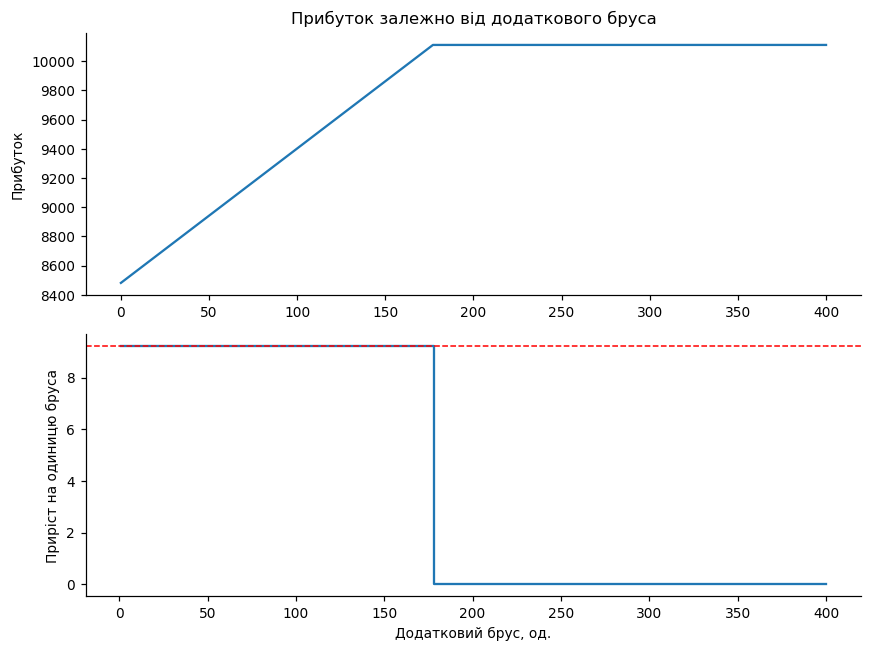

In [121]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

ax[0].plot(add, profit)
ax[0].set_ylabel('Прибуток')
ax[0].set_title('Прибуток залежно від додаткового бруса')

ax[1].step(add[1:], increase, where='post')
ax[1].axhline(9.2143, color='red', ls='--', lw=1)
ax[1].set_ylabel('Приріст на одиницю бруса')
ax[1].set_xlabel('Додатковий брус, од.')

plt.tight_layout()
plt.show()


**Відповідь 5.2:**

Як бачимо з першого графіку, у нас зі збільшенням запасу дерев'яних брусків зростає прибуток, проте в діапазоні 150 - 200 у нас досягється пік зростання і далі просто пряма. Тобто зі збільшенням запасів бруска, прибуток не збільшується.

На другому графіку пунктирна червона лінія - це тіньова ціна за 1 брусок. З графіка видно, що з кожним додатковим бруском ми отримуватимемо 9.21 прибутку. Далі йде різкий спад теж в діапазоні 150-200, що означає, що далі бруски надлишкові і не будуть приносити прибутку. Інакше кажучи, запаси стають надлишковими.

Зі звіту Solver в Excel допустиме збільшення було 177, що лягає в наші межі.

---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [122]:
ціна = 5.4
межа = 177 
тіньова_ціна = 9.21428571428572                   
скільки_докупляти = [0, 100, 177, 250, 354]


r0 = linprog(-c, A_ub=A, b_ub=b, method='highs')
прибуток0 = -r0.fun

def чистий_прибуток(скільки):
    b_нове = b.copy()
    b_нове[0] += скільки
    r = linprog(-c, A_ub=A, b_ub=b_нове, method='highs')
    return -r.fun - ціна * скільки

прогноз = межа * (тіньова_ціна - ціна)
print(f"Очікуваний виграш: {прогноз:.2f}")

for k in скільки_докупляти:
    print(f"Докупляємо {k:3d} брусків: чистий прибуток {чистий_прибуток(k):.2f}, "
          f"виграш {чистий_прибуток(k) - прибуток0:+.2f}")

Очікуваний виграш: 675.13
Докупляємо   0 брусків: чистий прибуток 8481.07, виграш +0.00
Докупляємо 100 брусків: чистий прибуток 8862.50, виграш +381.43
Докупляємо 177 брусків: чистий прибуток 9156.20, виграш +675.13
Докупляємо 250 брусків: чистий прибуток 8762.00, виграш +280.93
Докупляємо 354 брусків: чистий прибуток 8200.40, виграш -280.67


**Відповідь 6.1:**

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА

ресурс: Дубовий брус, м

ціна:   5.4 за одиницю

обсяг:  до 354 одиниць


* Брати чи ні і чому: Брати сенс є, оскільки, тіньова ціна покриває витрати на ресурс. Чистий прибуток: 3.81 на ресурс.
* Скільки одиниць має сенс купити і чому не більше: Має сенс докупляти 177 одиниць. Не більше, тому що тіньова ціна перестає діяти для надлишкових ресурсів.
* Очікуваний виграш: 675.13 од.
* Перевірка прямим розв'язанням дала:

при запасі: 613 + 177 = 790

прибуток: 177 · 9,2143 = +1630,93

витрати: 177 · 5,4 = 955,80

чистий прибуток: 1630,93 − 955,80 = 675,13 (виграш)

Якщо б докупили більше, наприклад, 354, то:

запас: 613 + 354 = 967

прибуток: 177 · 9,2143 + (354 - 177) · 0 = +1630,93
(тіньова ціна діє лише на перші 177 одиниць, решта не дає приросту)

витрати: 354 · 5,4 = 1911,60

чистий прибуток: 1630,93 − 1911,60 = −280,67 (збиток)



---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [123]:
ненульових = int(np.sum(план > 1e-6))
звязних = int(np.sum(np.isclose(A @ план, b, atol=1e-6)))
print(ненульових, звязних)


2 2


In [124]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 2 | зв’язних обмежень: 2
Етап 7 пройдено


**Відповідь 7.1:** Ненульових виробів 2 (крісло і лава), зв'язних обмежень теж 2 (брус і фанера), тобто числа збіглися. Це означає от що: якщо пригадати раніше, то ми встановили, що є дефіцитні ресурси (брус і фанера). Саме вони обмежують випуск виробів, а решта ресурсів у надлишку. Стілець і табурет випали, бо їній прибуток за тіньовою ціною не перекриває витрати. А от з кріслом і лавою навпаки, їхня вартість і прибуток рівнозначні. Тому логічно визначити, що краще підприємству виробляти, маючи обмежені ресурси, щоб не піти в мінус.

Якби числа не збіглися, це був би сигнал про особливий випадок: наприклад, ресурс витрачено повністю, але його тіньова ціна нуль, або існує кілька різних планів з однаковим прибутком. Тоді звіт про стійкість треба читати обережно.

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [125]:
"""округлення"""

план_окр = np.round(план) 
прибуток_окр = c @ план_окр 
допустимий = bool(np.all(A @ план_окр <= b))
print(план_окр, прибуток_окр, допустимий)

[120.   0.   0.  13.] 8499.0 False


In [126]:
"""цілочисельний оптимум"""

r_opt = linprog(-c, A_ub=A, b_ub=b, method='highs', integrality=1)
прибуток_opt = -r_opt.fun
план_opt = r_opt.x
допустимий = bool(np.all(A @ план_opt <= b))
print(план_opt, прибуток_opt, допустимий)


[120.   0.   0.  12.] 8436.0 True


**Відповідь 8.1:**

| Варіант | План | Прибуток | Допустимий? |
|---|---|---|---|
| без умови цілочисельності | [120.07142857   0.           0.          12.64285714] | 8481.071428571426 | так |
| округлений | [120.   0.   0.  13.] | 8499.0 | ні |
| цілочисельний оптимум | [120.   0.   0.  12.] | 8436.0 | так  |

**Висновок:** Округлювати не можна, тому що план, заокруглений в більшу сторону буде порушувати наші обмеження по ресурсах. Також прибуток дуже сильно перевищив межу, яку розв'язав Solve та linprog.


---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [127]:
постачальники = ['Полтава', 'Авдіївка', 'Ніжин']
споживачі     = ['Яремче', 'Рогатин', 'Новояворівськ', 'Алмазна']
D = np.array([[1014, 860, 915, 444],
              [1208, 1145, 1278, 137],
              [826, 671, 727, 741]])
запас = [30, 45, 25]
попит = [20, 25, 35, 20]

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Яремче,Рогатин,Новояворівськ,Алмазна
Полтава,1014,860,915,444
Авдіївка,1208,1145,1278,137
Ніжин,826,671,727,741


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [128]:
%pip install "pulp<4"

Note: you may need to restart the kernel to use updated packages.


In [129]:
import pulp

m, n = D.shape

модель = pulp.LpProblem('transport', pulp.LpMinimize)
x = [[pulp.LpVariable(f'x_{i}_{j}', lowBound=0) for j in range(n)] for i in range(m)]

модель += pulp.lpSum(D[i, j] * x[i][j] for i in range(m) for j in range(n))

for i in range(m):
    модель += (pulp.lpSum(x[i][j] for j in range(n)) == запас[i], f'запас_{i}')
for j in range(n):
    модель += (pulp.lpSum(x[i][j] for i in range(m)) == попит[j], f'попит_{j}')

модель.solve(pulp.PULP_CBC_CMD(msg=0))

план1 = np.array([[x[i][j].value() for j in range(n)] for i in range(m)])
вартість1 = pulp.value(модель.objective)
тіньові1 = np.array([модель.constraints[f'запас_{i}'].pi for i in range(m)] +
                    [модель.constraints[f'попит_{j}'].pi for j in range(n)])

print('Вартість:', вартість1)
print(pd.DataFrame(план1, index=постачальники, columns=споживачі))
print('Тіньові ціни:', dict(zip(['запас ' + p for p in постачальники] +
                                 ['попит ' + s for s in споживачі], тіньові1.round(2))))

Вартість: 77130.0
          Яремче  Рогатин  Новояворівськ  Алмазна
Полтава      0.0      0.0           30.0      0.0
Авдіївка    20.0      5.0            0.0     20.0
Ніжин        0.0     20.0            5.0      0.0
Тіньові ціни: {'запас Полтава': np.float64(188.0), 'запас Авдіївка': np.float64(474.0), 'запас Ніжин': np.float64(0.0), 'попит Яремче': np.float64(734.0), 'попит Рогатин': np.float64(671.0), 'попит Новояворівськ': np.float64(727.0), 'попит Алмазна': np.float64(-337.0)}


In [130]:
c_т = D.flatten()                       

A_eq = np.zeros((m + n, m * n))
for i in range(m):
    A_eq[i, i * n:(i + 1) * n] = 1      
for j in range(n):
    A_eq[m + j, j::n] = 1               
b_eq = np.array(запас + попит, float)

r2 = linprog(c_т, A_eq=A_eq, b_eq=b_eq, method='highs')

план2 = r2.x.reshape(m, n)
вартість2 = r2.fun
тіньові2 = r2.eqlin.marginals           

print('Вартість:', вартість2)
print(pd.DataFrame(план2, index=постачальники, columns=споживачі))
print('Тіньові ціни:', dict(zip(['запас ' + p for p in постачальники] +
                                 ['попит ' + s for s in споживачі], тіньові2.round(2))))

Вартість: 77130.0
          Яремче  Рогатин  Новояворівськ  Алмазна
Полтава      0.0      0.0           30.0      0.0
Авдіївка    20.0      5.0            0.0     20.0
Ніжин        0.0     20.0            5.0      0.0
Тіньові ціни: {'запас Полтава': np.float64(-0.0), 'запас Авдіївка': np.float64(286.0), 'запас Ніжин': np.float64(-188.0), 'попит Яремче': np.float64(922.0), 'попит Рогатин': np.float64(859.0), 'попит Новояворівськ': np.float64(915.0), 'попит Алмазна': np.float64(-149.0)}


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [131]:
п = np.round(тіньові1, 2) + 0
л = np.round(тіньові2, 2) + 0

таблиця = pd.DataFrame({
    'Обмеження': ['запас'] * m + ['попит'] * n,
    'pulp': п,
    'linprog': л,
    'різниця': п - л,
}, index=постачальники + споживачі)

таблиця

,Обмеження,pulp,linprog,різниця
Полтава,запас,188.0,0.0,188.0
Авдіївка,запас,474.0,286.0,188.0
Ніжин,запас,0.0,-188.0,188.0
Яремче,попит,734.0,922.0,-188.0
Рогатин,попит,671.0,859.0,-188.0
Новояворівськ,попит,727.0,915.0,-188.0
Алмазна,попит,-337.0,-149.0,-188.0


**Відповідь 10.2:**

* Вартість у двох розв'язувачів: pulp = linprog = 77130.0
* Тіньові ціни збіглися чи ні: Ні
* Яку закономірність ви побачили в різниці: різниця pulp − linprog для всіх трьох постачальників однакова (+188), а для всіх чотирьох споживачів та сама зі знаком мінус (−188).
* Що це означає для того, хто збирається ухвалювати рішення за цим звітом: 

спиратись на окремі числа не треба, бо вони різняться в кожної бібліотеки, яку використовували. Якщо просумувати тіньову ціну постачальника і тіньову ціну споживача, то сума виходить однаковою в обох розв'язувачах (наприклад, Полтава + Яремче = 188 + 734 = 0 + 922 = 922). Така сума вже має зміст, який можна трактувати так: на стільки зросте сумарний пробіг, якщо в Полтаві з'явиться додаткова одиниця запасу, а Яремче замовить на одиницю більше. На основі цього можна оцінити, скільки коштуватиме додаткове замовлення: якщо помножити 922 на вартість перевезення однієї одиниці товару на один кілометр, отримаємо витрати на доставку цієї одиниці товару, і за цим розрахунком можна встановити ціну для замовника.


---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [132]:
ненульових_т = int(np.sum(план2 > 1e-6))
звязних_т = int(np.sum(np.isclose(A_eq @ план2.flatten(), b_eq, atol=1e-6)))

print('Ненульових перевезень:', ненульових_т)
print('Зв\'язних обмежень:', звязних_т)

Ненульових перевезень: 6
Зв'язних обмежень: 7


**Відповідь 11.1:**

* Ненульових перевезень: 6
* Зв'язних обмежень: 7
* Чому в транспортній задачі зв'язними виявляються **всі** обмеження: бо всі вони є рівностями: з кожного складу треба вивезти рівно стільки, скільки там є, а кожен споживач має отримати рівно стільки, скільки просить. Не більше і не менше. У виробничій задачі обмеження були були у вигляді нерівностей і частина ресурсів могла бути невикористаною.
* На скільки ненульових перевезень менше і чому саме на стільки: 

одне обмеження зайве, тому що воно стосується того, що сума запасів рівна сумі попиту: усе, що вивезли зі складів, має бути завезено в магазини. Тому, якщо виконано будь-які шість обмежень, сьоме виконується саме собою.


### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

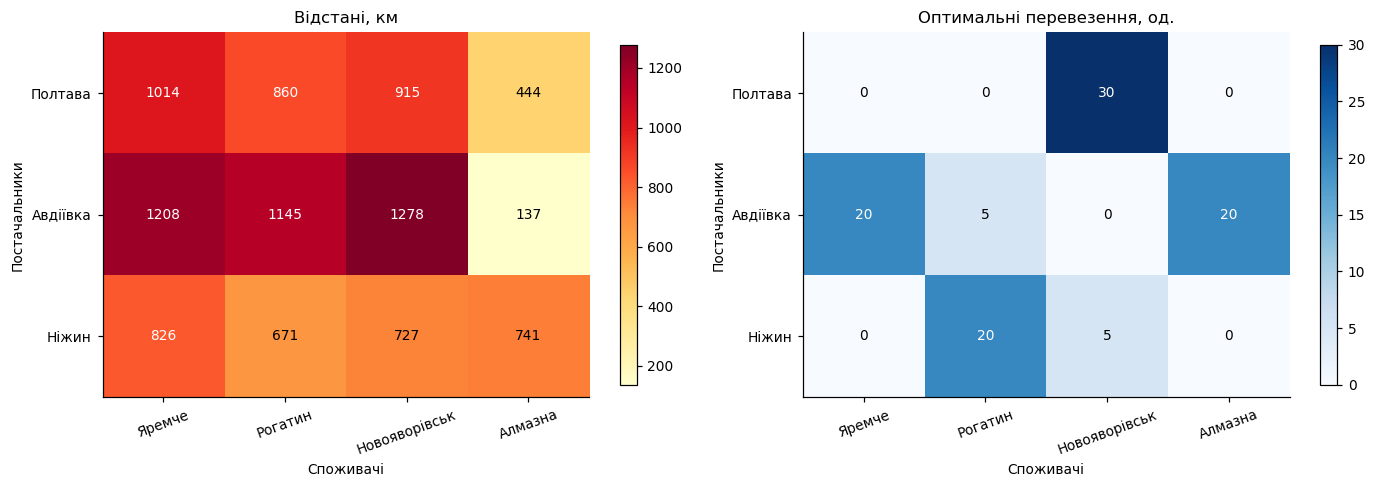

In [133]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

for a, M, назва, cmap in [(ax[0], D, 'Відстані, км', 'YlOrRd'),
                          (ax[1], план2, 'Оптимальні перевезення, од.', 'Blues')]:
    im = a.imshow(M, cmap=cmap)
    a.set_xticks(range(n)); a.set_xticklabels(споживачі, rotation=20)
    a.set_yticks(range(m)); a.set_yticklabels(постачальники)
    a.set_xlabel('Споживачі'); a.set_ylabel('Постачальники')
    a.set_title(назва)
    for i in range(m):
        for j in range(n):
            знач = M[i, j]
            колір = 'white' if знач > M.max() * 0.6 else 'black'
            a.text(j, i, f'{знач:.0f}', ha='center', va='center', color=колір)
    fig.colorbar(im, ax=a, shrink=0.8)

plt.tight_layout()
plt.show()

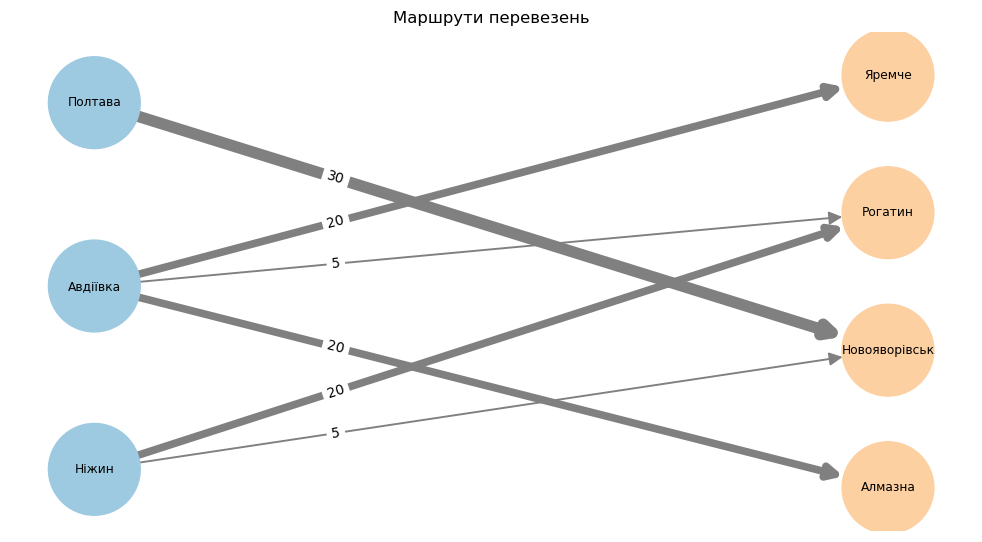

In [134]:
import networkx as nx

G = nx.DiGraph()
for i, p in enumerate(постачальники):
    G.add_node(p, pos=(0, -i))                     
for j, s in enumerate(споживачі):
    G.add_node(s, pos=(1, -j * 0.75 + 0.15))      

for i, p in enumerate(постачальники):
    for j, s in enumerate(споживачі):
        if план2[i, j] > 1e-6:                    
            G.add_edge(p, s, обсяг=план2[i, j])

pos = nx.get_node_attributes(G, 'pos')
ширини = [G[u][v]['обсяг'] / 4 for u, v in G.edges]            
підписи = {(u, v): f"{G[u][v]['обсяг']:.0f}" for u, v in G.edges}
кольори = ['#9ecae1'] * m + ['#fdd0a2'] * n                    

fig, ax = plt.subplots(figsize=(9, 5))
nx.draw_networkx_nodes(G, pos, node_color=кольори, node_size=3600, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
nx.draw_networkx_edges(G, pos, width=ширини, edge_color='gray', arrows=True,
                       arrowsize=18, node_size=3600, ax=ax)
nx.draw_networkx_edge_labels(G, pos, edge_labels=підписи, label_pos=0.3, font_size=9, ax=ax)
ax.set_title('Маршрути перевезень')
ax.axis('off')
plt.tight_layout()
plt.show()

**Висновок:** Задіяно лише 6 з 12 маршрутів, і як бачимо план не завжди обирає найближчий склад для магазину (Яремче отримує товар з найдальшої Авдіївки, 1208 км), бо суть транспортної задачі - мінімізувати сумарний пробіг усієї мережі, а не відстань для кожного споживача окремо.

---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [135]:
ІНСТРУМЕНТИ_ШІ = 'Claude'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'ні',
    'етап 2, побудова моделі в Excel':      'ні',
    'етап 3, код на Python':                'код, перевірено',
    'етапи 4–5, читання та перевірка звіту': 'текст, перероблено',
    'етап 6, рішення про закупівлю':        'код, перевірено',
    'етапи 7–8, перевірка та цілочисельність': 'код, перевірено',
    'етапи 9–11, транспортна задача':       'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = (
    'Порівняла план і прибуток з Excel з результатом linprog.'
    'Перевірила тіньову ціну бруса експериментом +1 одиниця.'
    'Переконалась, що округлений план недопустимий.'
    'Порівняла pulp і linprog.'
    'Перевірила кількість ненульових обмежень та перевезень.'
)
# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [136]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Паничевська Ярина Ернестівна
інструменти:                               Claude
------------------------------------------------------------------------------
етап 1, формалізація моделі:               ні
етап 2, побудова моделі в Excel:           ні
етап 3, код на Python:                     код, перевірено
етапи 4–5, читання та перевірка звіту:     текст, перероблено
етап 6, рішення про закупівлю:             код, перевірено
етапи 7–8, перевірка та цілочисельність:   код, перевірено
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------
Порівняла план і прибуток з Excel з результатом linprog.Перевірила тіньову ціну бруса експериментом +1 одиниця.Переконалась, що округлений план недопустимий.Порівняла pulp і linprog.Перевірила кількість ненульових обмежень та перевезень.


---
# Крок 13. Фінальна самоперевірка

In [137]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
